# Skewness Analysis — Transformation Method Comparison

Compares the effect of 5 transformation methods on feature skewness.

**Features:** 12 continuous numeric features (binary features excluded)  
**Methods:** Raw, log1p, sqrt, Box-Cox, Yeo-Johnson, Cube root

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer

import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

SKEW_THRESH = 0.5

COLORS = {
    'Raw':         '#239DD9',
    'log1p':       '#239DD9',
    'sqrt':        '#FF911E',
    'Box-Cox':     '#55a868',
    'Yeo-Johnson': '#FF911E',
    'Cube Root':   '#c44e52',
}

print('Libraries loaded.')

Libraries loaded.


In [4]:
df = pd.read_csv('./datasets/phishing_url_features.csv')
print(f'Loaded: {len(df):,} rows x {df.shape[1]} columns')

CONTINUOUS_FEATURES = [
    'URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'PathDepth',
    'NoOfSubDomain', 'DigitRatioInURL', 'NoOfSpecialCharsInURL',
    'NoOfDots', 'NoOfDashInURL', 'DomainEntropy', 'NoOfQueryParams',
]

X = df[CONTINUOUS_FEATURES].copy()
print(f'Features: {len(CONTINUOUS_FEATURES)}')

Loaded: 5,183,050 rows x 29 columns
Features: 12


In [5]:
# ── Apply all transforms ───────────────────────────────────────────────────
results = {}
results['Raw'] = X.skew()

# log1p
results['log1p'] = np.log1p(X).skew()

# sqrt (shift negatives to 0 first)
X_sqrt = X.copy()
for col in CONTINUOUS_FEATURES:
    shift = max(0, -X_sqrt[col].min())
    X_sqrt[col] = np.sqrt(X_sqrt[col] + shift)
results['sqrt'] = X_sqrt.skew()

# Box-Cox (requires strictly positive — shift by min + 1)
pt_bc = PowerTransformer(method='box-cox')
X_bc = X.copy()
for col in CONTINUOUS_FEATURES:
    shift = max(0, 1 - X_bc[col].min())   # ensure all values > 0
    X_bc[col] = X_bc[col] + shift
results['Box-Cox'] = pd.Series(
    pt_bc.fit_transform(X_bc).std(axis=0),  # use skewness after transform
    index=CONTINUOUS_FEATURES
)
# recompute skewness properly
results['Box-Cox'] = pd.DataFrame(
    pt_bc.fit_transform(X_bc), columns=CONTINUOUS_FEATURES
).skew()

# Yeo-Johnson (handles zeros and negatives natively)
pt_yj = PowerTransformer(method='yeo-johnson')
results['Yeo-Johnson'] = pd.DataFrame(
    pt_yj.fit_transform(X), columns=CONTINUOUS_FEATURES
).skew()

# Cube root (handles negatives, weaker than log1p for heavy tails)
results['Cube Root'] = np.cbrt(X).skew()

skew_df = pd.DataFrame(results).round(3)
skew_df = skew_df.reindex(skew_df['Raw'].sort_values(ascending=False).index)

print('Skewness comparison across transforms:')
display(skew_df.style
    .background_gradient(cmap='RdYlGn_r', axis=None)
    .format('{:.3f}')
)

Skewness comparison across transforms:


,Raw,log1p,sqrt,Box-Cox,Yeo-Johnson,Cube Root
NoOfSpecialCharsInURL,15.413,0.940,2.695,-0.004,-0.004,1.805
URLLength,6.707,0.481,1.727,-0.006,-0.005,1.197
NoOfQueryParams,6.053,2.380,2.263,1.666,1.666,1.891
NoOfSubDomain,5.691,2.648,2.662,1.746,1.746,2.131
PathLength,4.939,-0.984,0.581,0.028,0.028,-0.083
NoOfDots,4.342,0.929,1.689,0.010,0.010,1.188
TLDLength,3.018,1.322,1.865,0.004,0.000,1.527
NoOfDashInURL,2.799,0.844,0.897,0.298,0.298,0.386
PathDepth,2.534,-0.333,-0.271,0.012,0.012,-1.426
DigitRatioInURL,1.650,1.429,0.525,0.430,0.430,0.112


In [6]:
# ── Count features within ±0.5 threshold per method ──────────────────────
summary = pd.DataFrame({
    'Method': list(results.keys()),
    'Within ±0.5': [(results[m].abs() <= SKEW_THRESH).sum() for m in results],
    'Mean |Skew|':  [results[m].abs().mean().round(3) for m in results],
    'Max |Skew|':   [results[m].abs().max().round(3) for m in results],
}).set_index('Method')
print('Summary — features within ±0.5 skewness threshold:')
display(summary.style.highlight_max(subset=['Within ±0.5'], color='#239DD9').format({'Mean |Skew|': '{:.3f}', 'Max |Skew|': '{:.3f}'}))

Summary — features within ±0.5 skewness threshold:


,Within ±0.5,Mean |Skew|,Max |Skew|
Method,,,
Raw,0,4.591,15.413
log1p,3,1.177,2.648
sqrt,2,1.428,2.695
Box-Cox,10,0.359,1.746
Yeo-Johnson,10,0.358,1.746
Cube Root,4,1.228,2.944


## Chart 1 — Raw Skewness

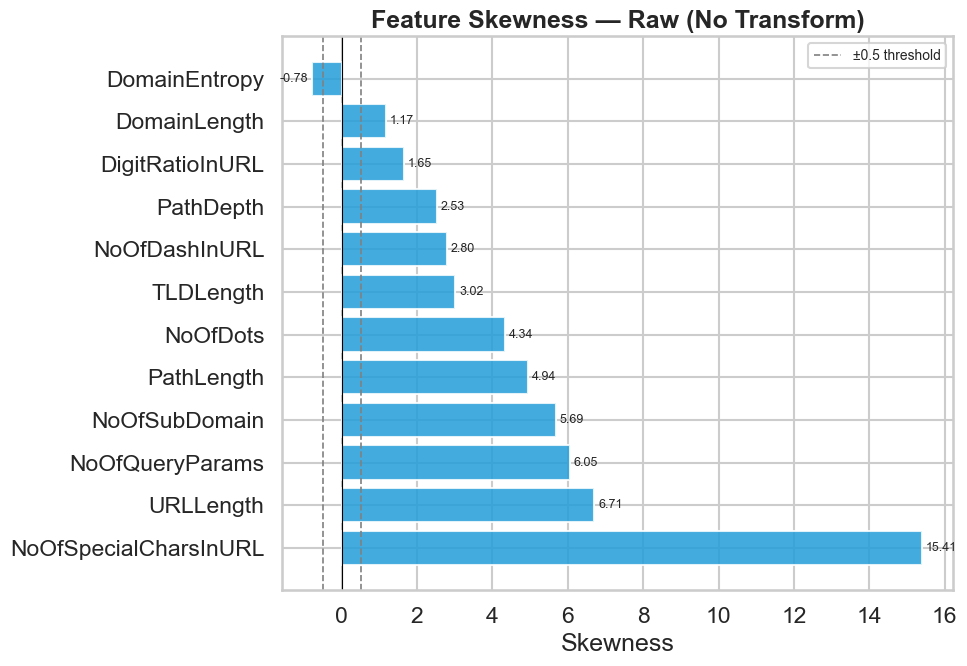

In [15]:
def plot_skew(series, title, color):
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(series.index, series.values, color=color, alpha=0.85)
    ax.axvline(x= SKEW_THRESH, color='grey', linestyle='--', linewidth=1.2, label=f'±{SKEW_THRESH} threshold')
    ax.axvline(x=-SKEW_THRESH, color='grey', linestyle='--', linewidth=1.2)
    ax.axvline(x=0, color='black', linewidth=0.8)
    for bar, val in zip(bars, series.values):
        offset = 0.1 if val >= 0 else -0.1
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_xlabel('Skewness')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

plot_skew(skew_df['Raw'], 'Feature Skewness — Raw (No Transform)', COLORS['Raw'])

## Chart 2 — After log1p

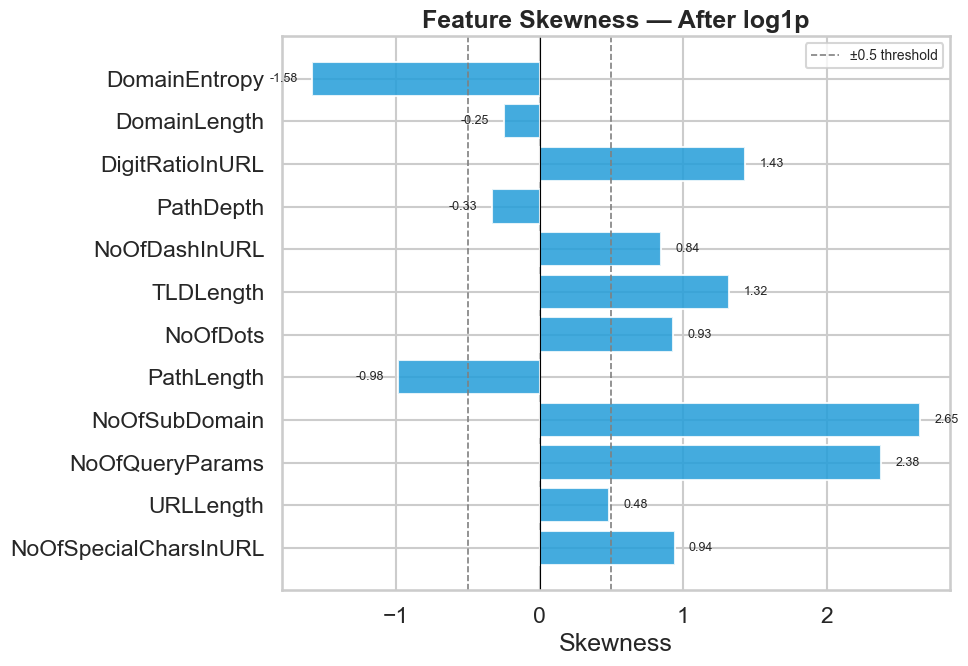

In [8]:
plot_skew(skew_df['log1p'], 'Feature Skewness — After log1p', COLORS['log1p'])

## Chart 3 — After sqrt

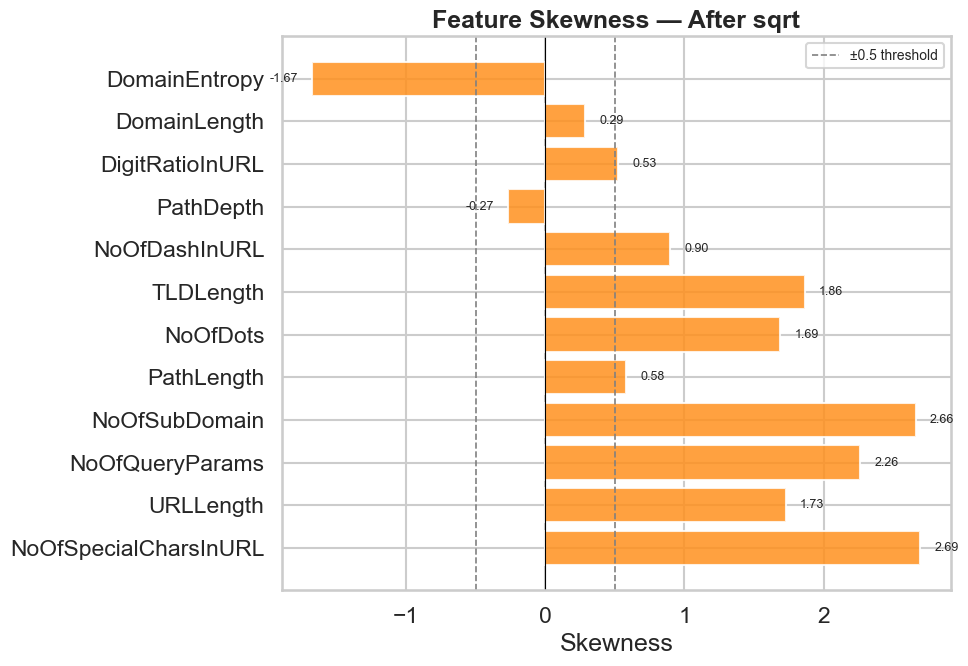

In [9]:
plot_skew(skew_df['sqrt'], 'Feature Skewness — After sqrt', COLORS['sqrt'])

## Chart 4 — After Box-Cox

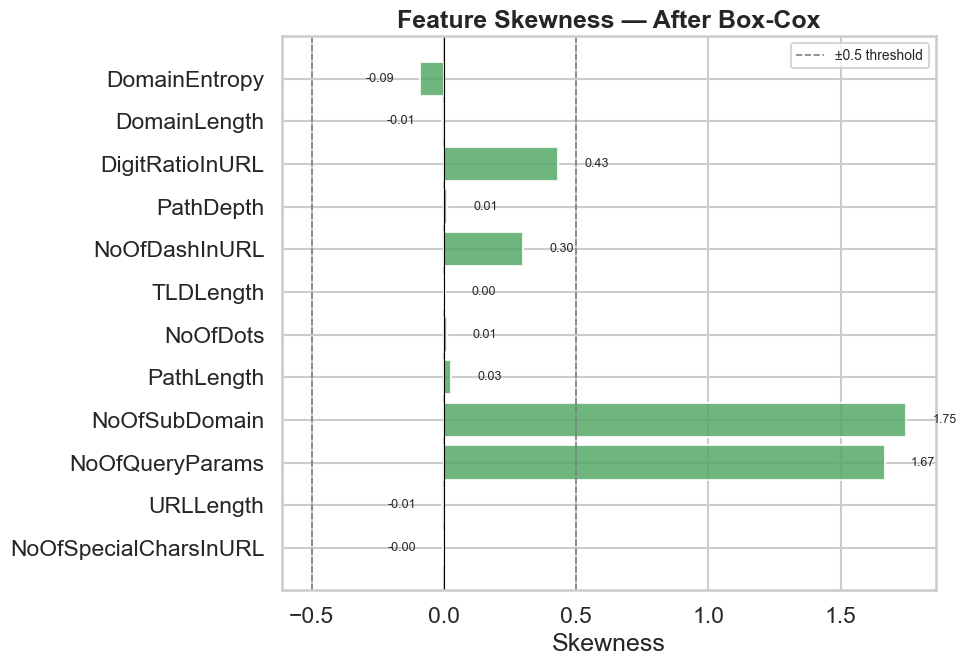

In [10]:
plot_skew(skew_df['Box-Cox'], 'Feature Skewness — After Box-Cox', COLORS['Box-Cox'])

## Chart 5 — After Yeo-Johnson

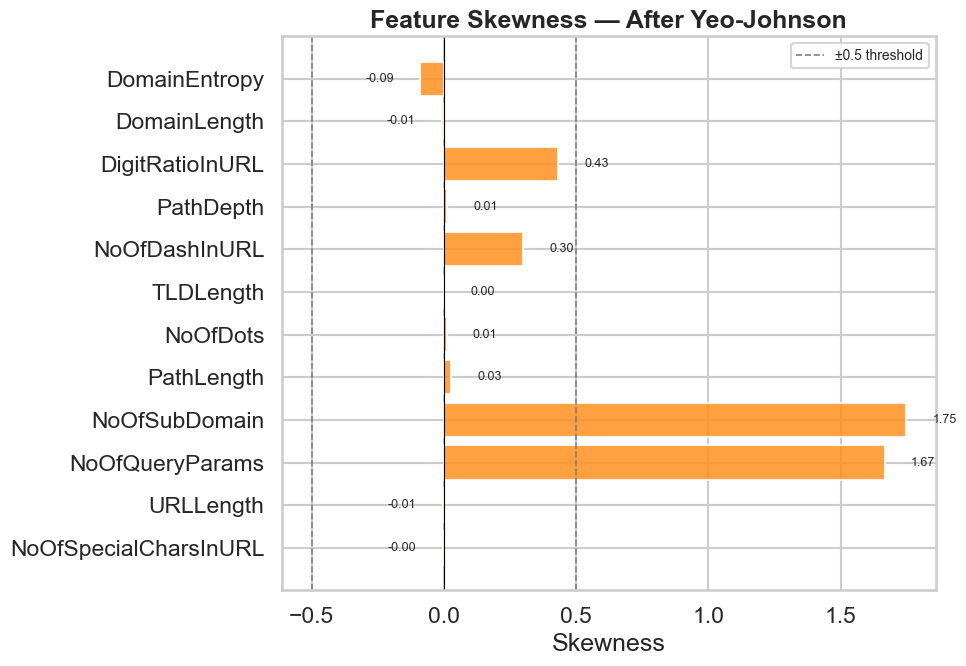

In [16]:
plot_skew(skew_df['Yeo-Johnson'], 'Feature Skewness — After Yeo-Johnson', COLORS['Yeo-Johnson'])

## Chart 6 — After Cube Root

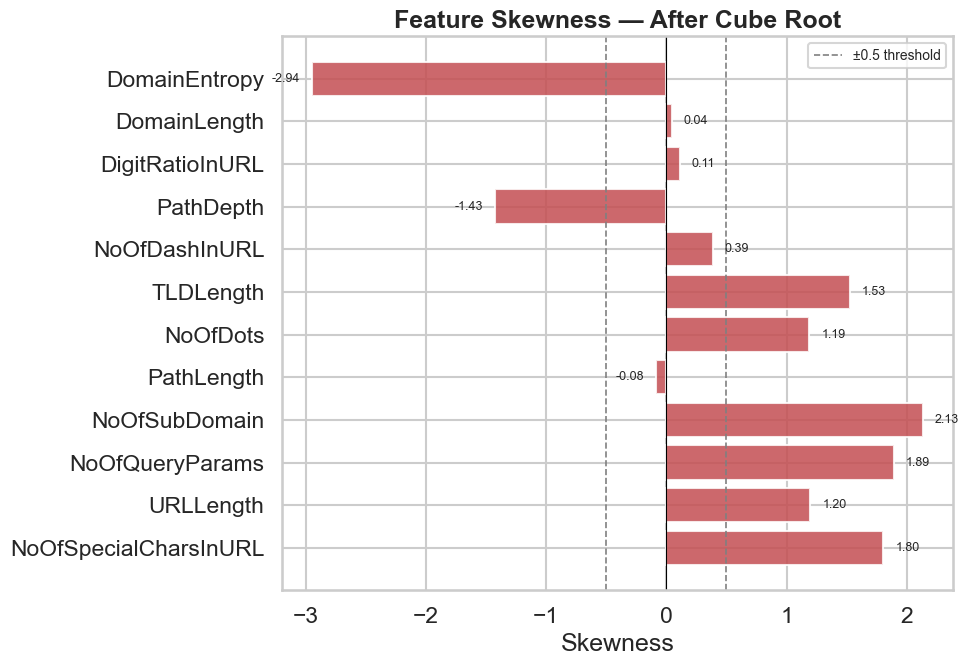

In [12]:
plot_skew(skew_df['Cube Root'], 'Feature Skewness — After Cube Root', COLORS['Cube Root'])

## Chart 7 — All Methods Side by Side

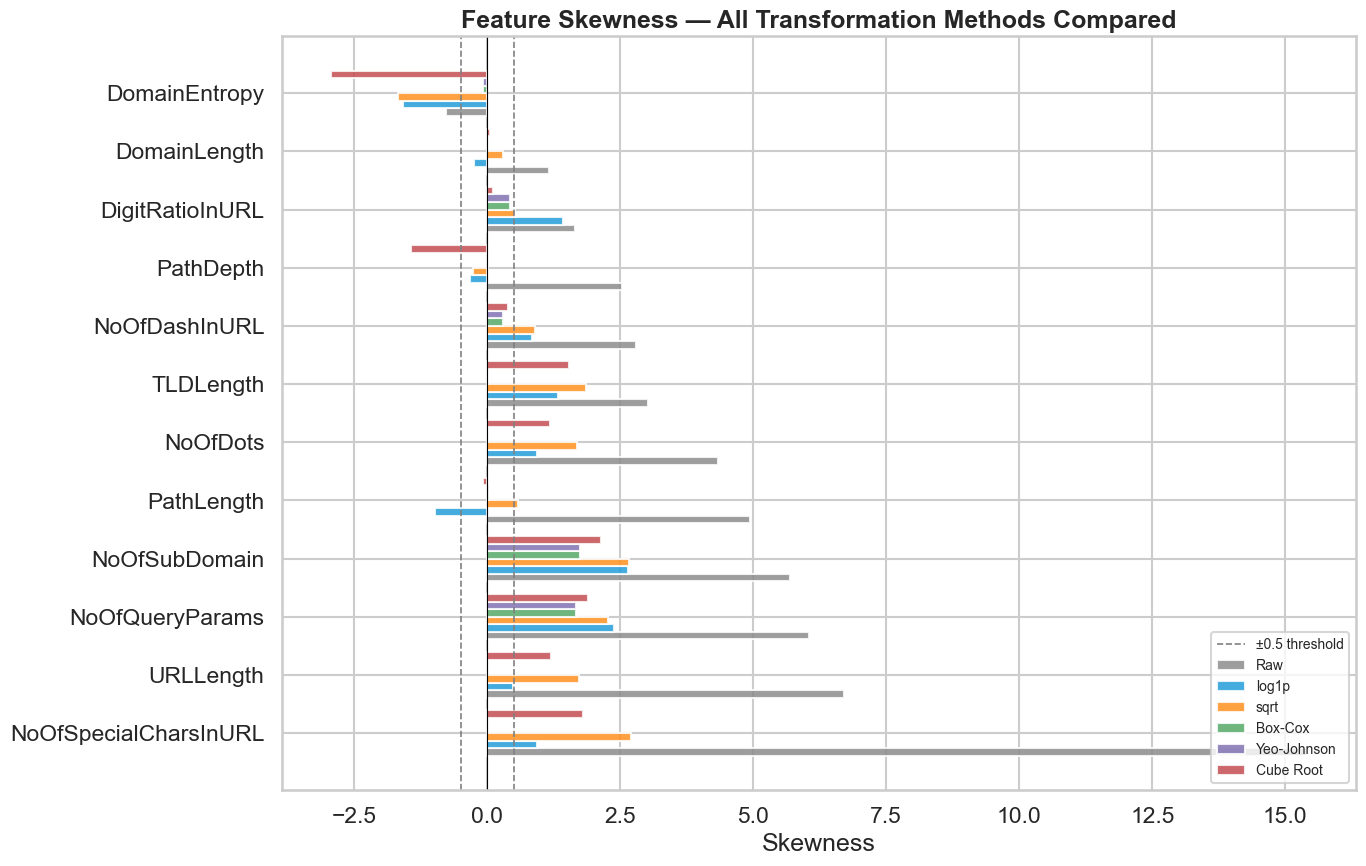

In [13]:
methods = list(results.keys())
n_methods = len(methods)
n_features = len(CONTINUOUS_FEATURES)
features = skew_df.index.tolist()

y = np.arange(n_features)
height = 0.13

fig, ax = plt.subplots(figsize=(14, 9))
for i, method in enumerate(methods):
    offset = (i - n_methods / 2) * height + height / 2
    ax.barh(y + offset, skew_df[method].values, height=height,
            color=COLORS[method], alpha=0.85, label=method)

ax.axvline(x= SKEW_THRESH, color='grey', linestyle='--', linewidth=1.2, label=f'±{SKEW_THRESH} threshold')
ax.axvline(x=-SKEW_THRESH, color='grey', linestyle='--', linewidth=1.2)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(features)
ax.set_xlabel('Skewness')
ax.set_title('Feature Skewness — All Transformation Methods Compared', fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()